<a href="https://colab.research.google.com/github/Ashfaq223/Ashfaq123/blob/main/R_analytics_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Installing the necessary packages**

In [1]:
install.packages("ggplot2")
install.packages("dplyr")
install.packages("tidyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



**Using the libraries (ggplot2, dplyr & tidyr)**

In [2]:
library(ggplot2)
library(dplyr)
library(tidyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




**Loading the dataset**

In [3]:
orders     <- read.csv("Data set/8# cleaned_orders.csv",     stringsAsFactors = FALSE)
deliveries <- read.csv("Data set/4# cleaned_deliveries.csv", stringsAsFactors = FALSE)
complaints <- read.csv("Data set/2# cleaned_complaints.csv", stringsAsFactors = FALSE)
customers  <- read.csv("Data set/3# cleaned_customers.csv",  stringsAsFactors = FALSE)
drivers    <- read.csv("Data set/5# cleaned_drivers.csv",    stringsAsFactors = FALSE)
hubs       <- read.csv("Data set/6# cleaned_hubs.csv",       stringsAsFactors = FALSE)
vehicles   <- read.csv("Data set/9# cleaned_vehicles.csv",   stringsAsFactors = FALSE)
incidents  <- read.csv("Data set/7# cleaned_incidents.csv",  stringsAsFactors = FALSE)

**Cleaning the zone names**

In [4]:
clean_zone <- function(x) {
  x <- tolower(trimws(x))
  x <- gsub("^airport$",          "Airport",   x)
  x <- gsub("^north$",            "North",     x)
  x <- gsub("^south$",            "South",     x)
  x <- gsub("^east$",             "East",      x)
  x <- gsub("^west$",             "West",      x)
  x <- gsub("^central$|^ctr$",    "Central",   x)
  x <- gsub("^riverside$",        "Riverside", x)
  return(x)
}

In [5]:
orders$pickup_zone    <- clean_zone(orders$pickup_zone)
orders$dropoff_zone   <- clean_zone(orders$dropoff_zone)
drivers$base_zone     <- clean_zone(drivers$base_zone)
customers$home_zone   <- clean_zone(customers$home_zone)
vehicles$assigned_zone <- clean_zone(vehicles$assigned_zone)

cat("Zones are all cleaned\n")

Zones are all cleaned


**1st Analysis: Summary Statistics for Key Numeric Columns**

Before any visualisation, we look at the basic statistical summary of the most important numeric fields to understand the shape and the spread of data.

In [6]:
cat("\n Summary: Order Values \n")
summary(orders$order_value)

cat("\n Summary: Customer Ratings \n")
summary(deliveries$customer_rating_post_delivery)

cat("\n Summary: Driver Ratings \n")
summary(drivers$driver_rating)

cat("\n Summary: Compensation Amounts \n")
summary(complaints$compensation_amount)

cat("\n Summary: Route Distance (km) \n")
summary(deliveries$route_distance_km)


 Summary: Order Values 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.04   47.91   76.53   91.05  121.10  510.06 


 Summary: Customer Ratings 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   3.360   4.040   3.865   4.550   5.000 


 Summary: Driver Ratings 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.150   3.885   4.160   4.160   4.470   5.000 


 Summary: Compensation Amounts 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   8.822  18.405  20.257  29.145  61.850 


 Summary: Route Distance (km) 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.20    9.12   12.84   13.86   16.75   41.94 


**2nd Analysis: Delivery Status Distribution**

A simple count of how many deliveries were On Time, Delayed, or Failed across the entire operation.

In [7]:
status_counts <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(count = n())

cat("\n Delivery Status Counts \n")
print(status_counts)


 Delivery Status Counts 
# A tibble: 3 × 2
  delivery_status count
  <chr>           <int>
1 Delayed           197
2 Failed            131
3 OnTime            608


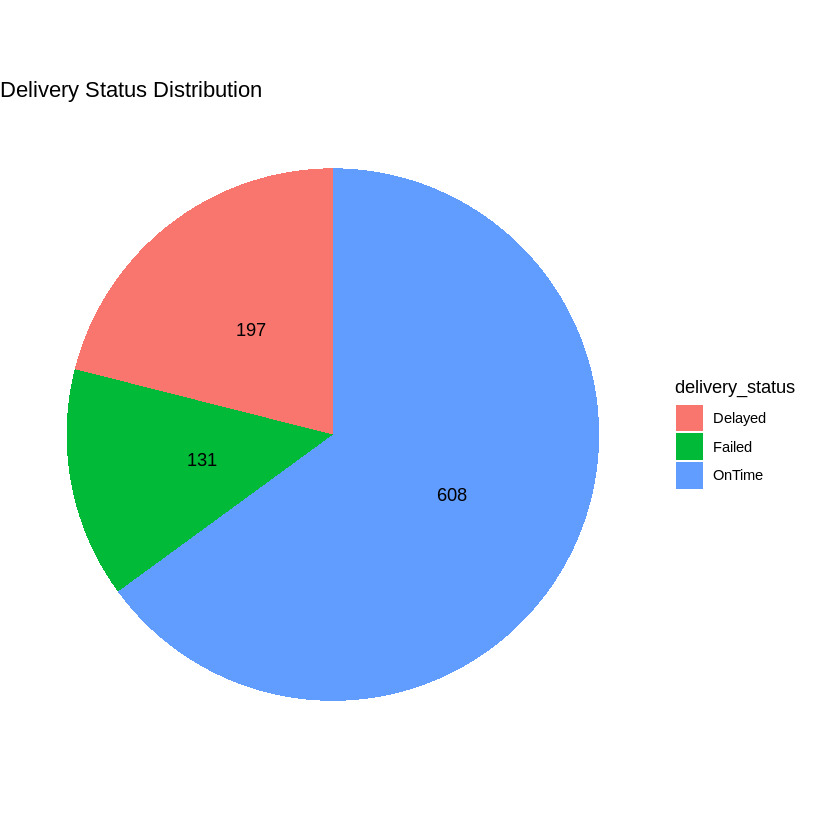

In [8]:
#2 Pie chart
ggplot(status_counts, aes(x = "", y = count, fill = delivery_status)) +
  geom_col(width = 1) +
  coord_polar(theta = "y") +
  geom_text(aes(label = count), position = position_stack(vjust = 0.5)) +
  labs(
    title = "Delivery Status Distribution"
  ) +
  theme_void()

**3rd ANALYSIS: Order Value Distribution by Service Type**

A boxplot shows us the spread of order values for each service type, revealing which services are more lucrative and which have more variability in pricing.

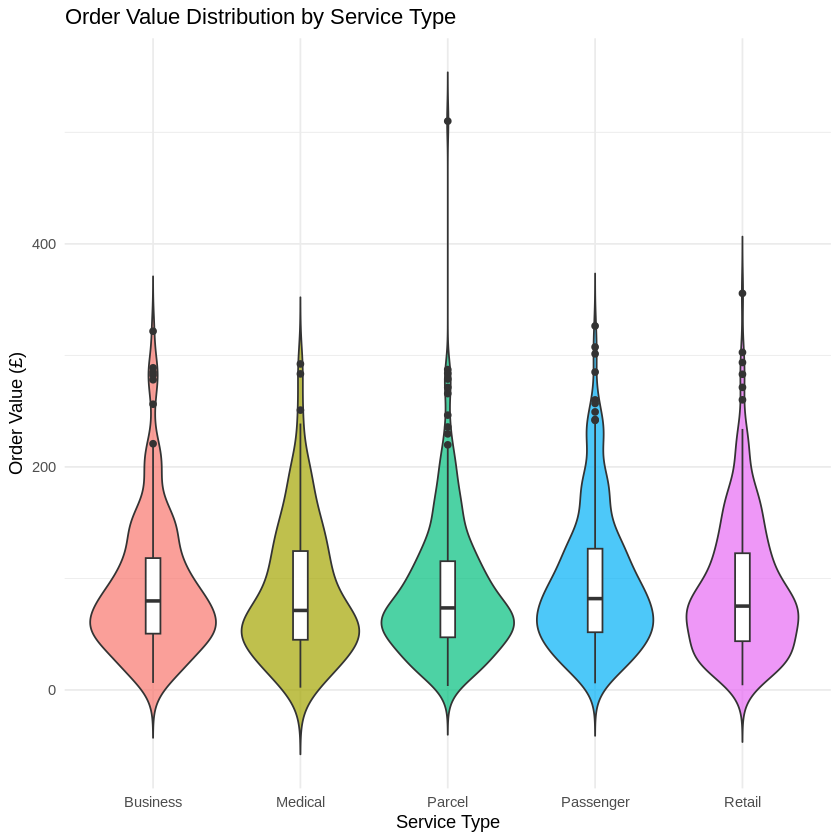

In [9]:
#1 Violin plot for distribution
ggplot(orders, aes(x = service_type, y = order_value, fill = service_type)) +
  geom_violin(trim = FALSE, alpha = 0.7) +
  geom_boxplot(width = 0.1, fill = "white") +
  labs(
    title = "Order Value Distribution by Service Type",
    x = "Service Type",
    y = "Order Value (£)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

**4th Analysis: Customer Rating Distribution**

A histogram shows how customer ratings are spread. A skew towards low ratings would indicate widespread dissatisfaction across the operation.

In [10]:
# Remove the missing ratings first

ratings_clean <- deliveries %>%
  filter(!is.na(customer_rating_post_delivery))

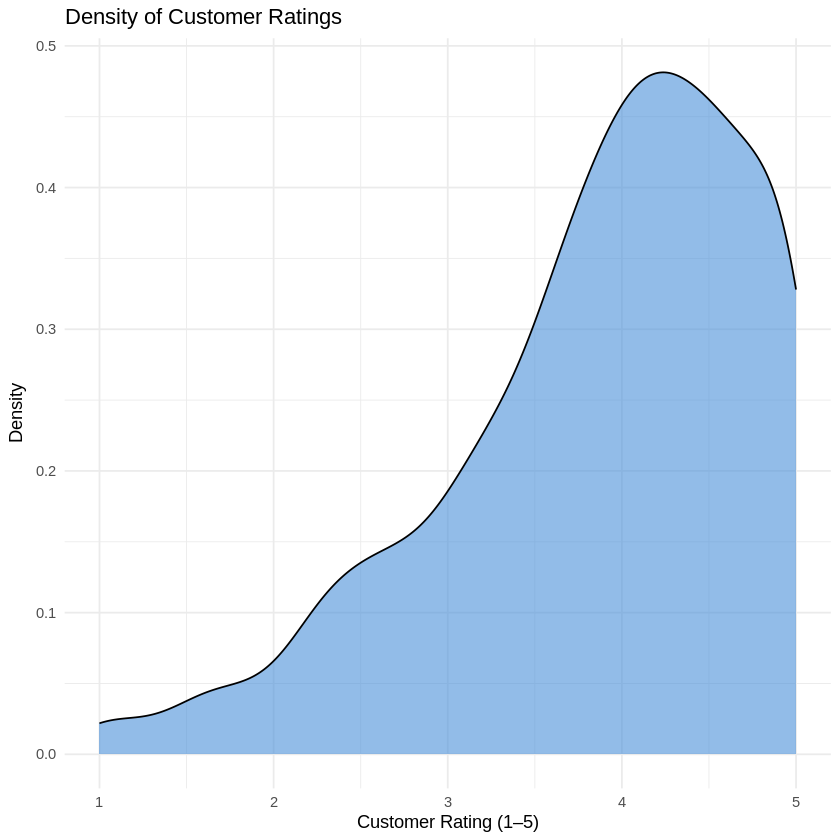

In [11]:
#2 Density plot
ggplot(ratings_clean, aes(x = customer_rating_post_delivery)) +
  geom_density(fill = "#4a90d9", alpha = 0.6) +
  labs(
    title = "Density of Customer Ratings",
    x = "Customer Rating (1–5)",
    y = "Density"
  ) +
  theme_minimal()


**5th Analysis: Correlation Between Driver Training and Rating**

We want to see if better trained drivers actually receive higher customer ratings. This can justify training investment.

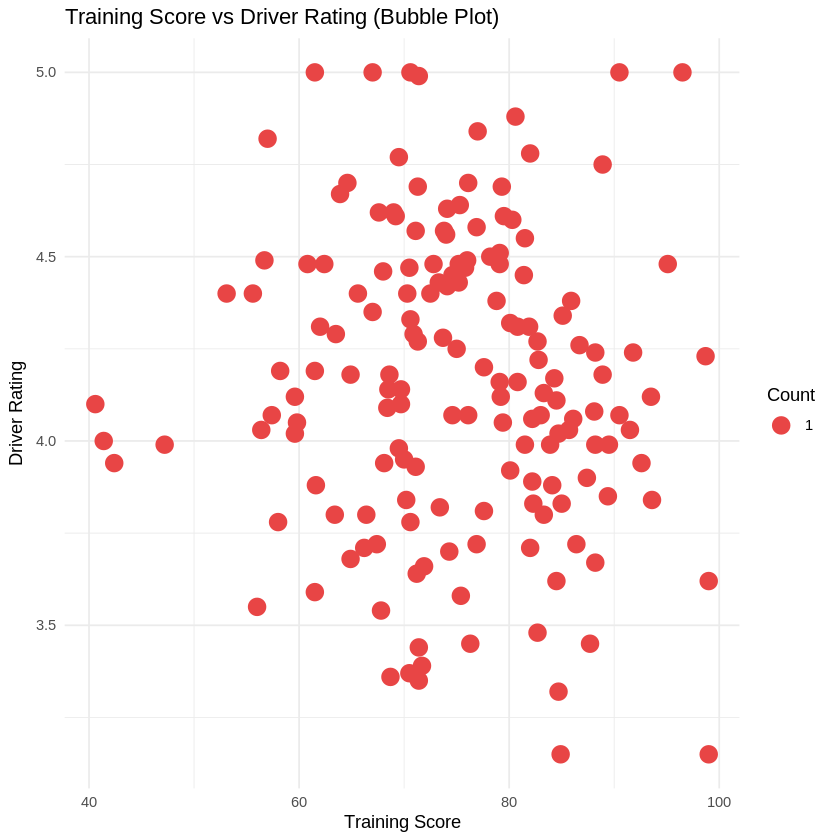

In [12]:
#1 Bubble plot (if you have repeated values or counts)
ggplot(drivers, aes(x = training_score, y = driver_rating)) +
  geom_count(color = "#e84545") +
  labs(
    title = "Training Score vs Driver Rating (Bubble Plot)",
    x = "Training Score",
    y = "Driver Rating",
    size = "Count"
  ) +
  theme_minimal()

In [13]:
# Print the correlation coefficient

cor_val <- cor(drivers$training_score, drivers$driver_rating, use = "complete.obs")
cat("\nCorrelation between training score and driver rating:", round(cor_val, 3), "\n")


Correlation between training score and driver rating: -0.07 



**6th Analysis: Vehicle Battery Health by Maintenance Status**

Vehicles in repair or scheduled maintenance should have lower battery health. This checks if the maintenance system is correctly identifying at-risk vehicles.

In [14]:
vehicles_clean <- vehicles %>%
  filter(!is.na(battery_health_pct))

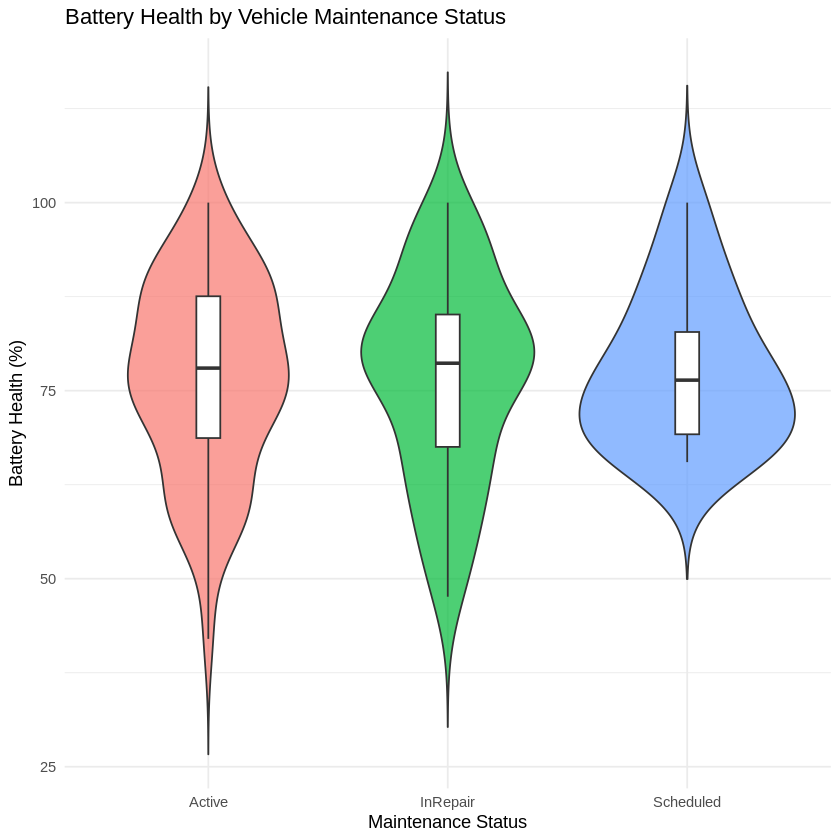

In [15]:
#1 Violin plot for battery health distribution
ggplot(vehicles_clean, aes(x = maintenance_status, y = battery_health_pct, fill = maintenance_status)) +
  geom_violin(trim = FALSE, alpha = 0.7) +
  geom_boxplot(width = 0.1, fill = "white") +
  labs(
    title = "Battery Health by Vehicle Maintenance Status",
    x = "Maintenance Status",
    y = "Battery Health (%)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

**7th Analysis: Complaint Frequency by Customer Type**

Are Enterprise customers complaining more than Consumer customers? This helps understand where service gaps are most damaging to the business relationship.

In [16]:
complaints_joined <- complaints %>%
  left_join(customers, by = "customer_id")

complaint_by_type <- complaints_joined %>%
  group_by(customer_type) %>%
  summarise(total_complaints = n(),
            avg_compensation  = round(mean(compensation_amount, na.rm = TRUE), 2))

cat("\n Complaints by Customer Type \n")
print(complaint_by_type)


 Complaints by Customer Type 
# A tibble: 4 × 3
  customer_type total_complaints avg_compensation
  <chr>                    <int>            <dbl>
1 Consumer                   221             20.6
2 Enterprise                  25             20.6
3 SME                         45             18.4
4 NA                          13             20.1


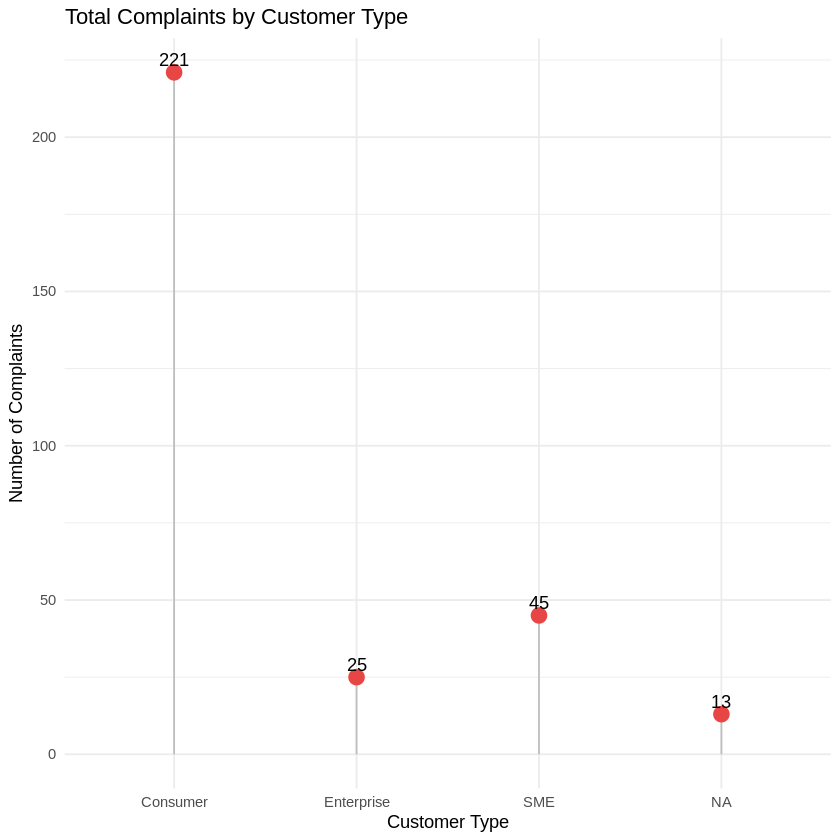

In [17]:
#1 Lollipop chart for complaints by customer type
ggplot(complaint_by_type, aes(x = customer_type, y = total_complaints)) +
  geom_segment(aes(x = customer_type, xend = customer_type,
                   y = 0, yend = total_complaints), color = "grey") +
  geom_point(size = 4, color = "#e84545") +
  geom_text(aes(label = total_complaints), vjust = -0.5) +
  labs(
    title = "Total Complaints by Customer Type",
    x = "Customer Type",
    y = "Number of Complaints"
  ) +
  theme_minimal()

**8th Analysis: Fuel/Charge Cost vs Route Distance**

There should be a positive relationship between how far a vehicle travels and how much fuel or charge it uses. Outliers may indicate inefficient routes or vehicle faults.

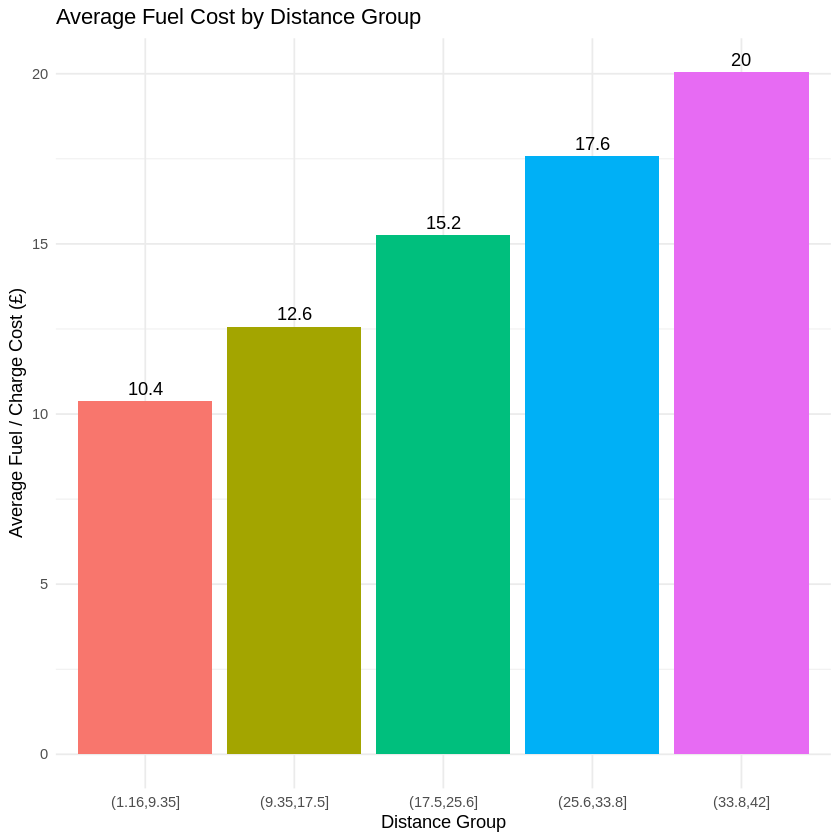

In [18]:
#3 Create distance groups
deliveries$distance_group <- cut(deliveries$route_distance_km, breaks = 5)

#4 Compute average cost per group
avg_cost <- aggregate(fuel_or_charge_cost ~ distance_group, data = deliveries, mean)

#5 Bar chart of averages
ggplot(avg_cost, aes(x = distance_group, y = fuel_or_charge_cost, fill = distance_group)) +
  geom_col() +
  geom_text(aes(label = round(fuel_or_charge_cost, 1)), vjust = -0.5) +
  labs(
    title = "Average Fuel Cost by Distance Group",
    x = "Distance Group",
    y = "Average Fuel / Charge Cost (£)"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

In [19]:
cor_cost <- cor(deliveries$route_distance_km, deliveries$fuel_or_charge_cost, use = "complete.obs")
cat("\nCorrelation between route distance and cost:", round(cor_cost, 3), "\n")


Correlation between route distance and cost: 0.527 


**9th Analysis: Incident Types Breakdown**

Understanding which incident types occur most frequently helps management prioritise where to focus operational improvements and safety investments.

In [20]:
incident_summary <- incidents %>%
  group_by(incident_type) %>%
  summarise(
    count            = n(),
    avg_resolved_hrs = round(mean(resolved_hours, na.rm = TRUE), 2)
  ) %>%
  arrange(desc(count))

cat("\n Incident Type Summary \n")
print(incident_summary)


 Incident Type Summary 
# A tibble: 8 × 3
  incident_type    count avg_resolved_hrs
  <chr>            <int>            <dbl>
1 CustomerNoShow      42            13.9 
2 RouteDeviation      41            13.7 
3 ProofMissing        40            10.8 
4 VehicleFault        36             9.15
5 BatteryAlert        34            11.7 
6 TemperatureIssue    29            12.9 
7 AppSyncError        28            12.7 
8 SafetyNearMiss      13             9.67


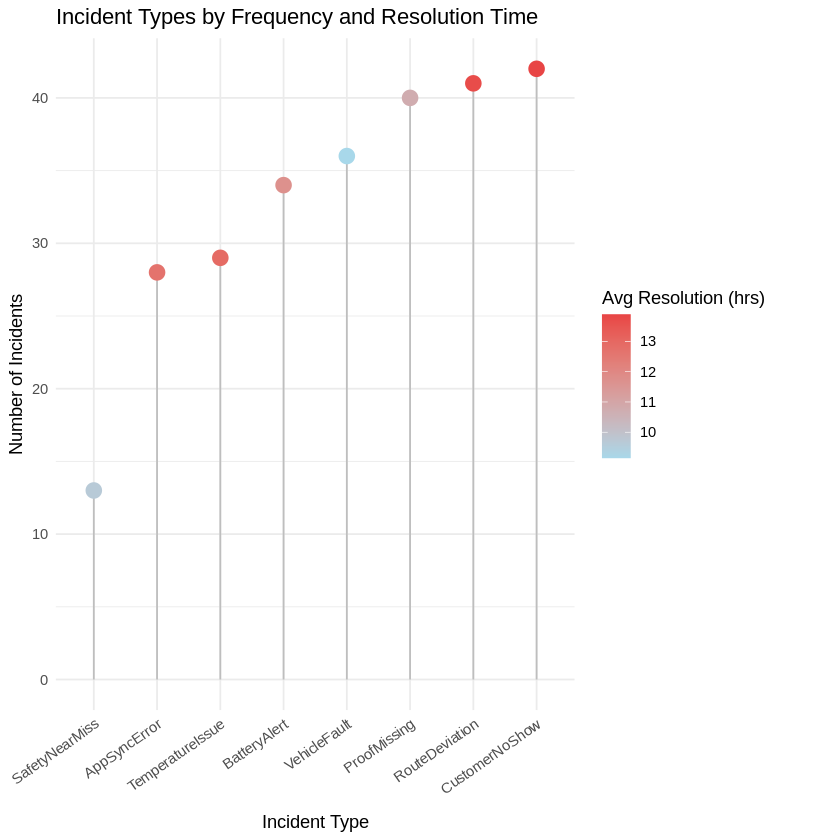

In [21]:
#1 Lollipop chart for incidents
ggplot(incident_summary, aes(x = reorder(incident_type, count), y = count)) +
  geom_segment(aes(x = incident_type, xend = incident_type,
                   y = 0, yend = count), color = "grey") +
  geom_point(aes(color = avg_resolved_hrs), size = 4) +
  scale_color_gradient(low = "#a8d8ea", high = "#e84545") +
  labs(
    title = "Incident Types by Frequency and Resolution Time",
    x = "Incident Type",
    y = "Number of Incidents",
    color = "Avg Resolution (hrs)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

**10th Analysis: Driver Experience vs Delivery Performance**

Do more experienced drivers have fewer failed deliveries? We join drivers with deliveries and compare failure rates across experience levels.

In [22]:
driver_performance <- deliveries %>%
  left_join(drivers, by = "driver_id") %>%
  filter(!is.na(years_experience)) %>%
  mutate(is_failed = ifelse(delivery_status == "Failed", 1, 0)) %>%
  group_by(years_experience) %>%
  summarise(
    total     = n(),
    failures  = sum(is_failed),
    fail_rate = round(100 * failures / total, 1)
  )

`geom_smooth()` using formula = 'y ~ x'


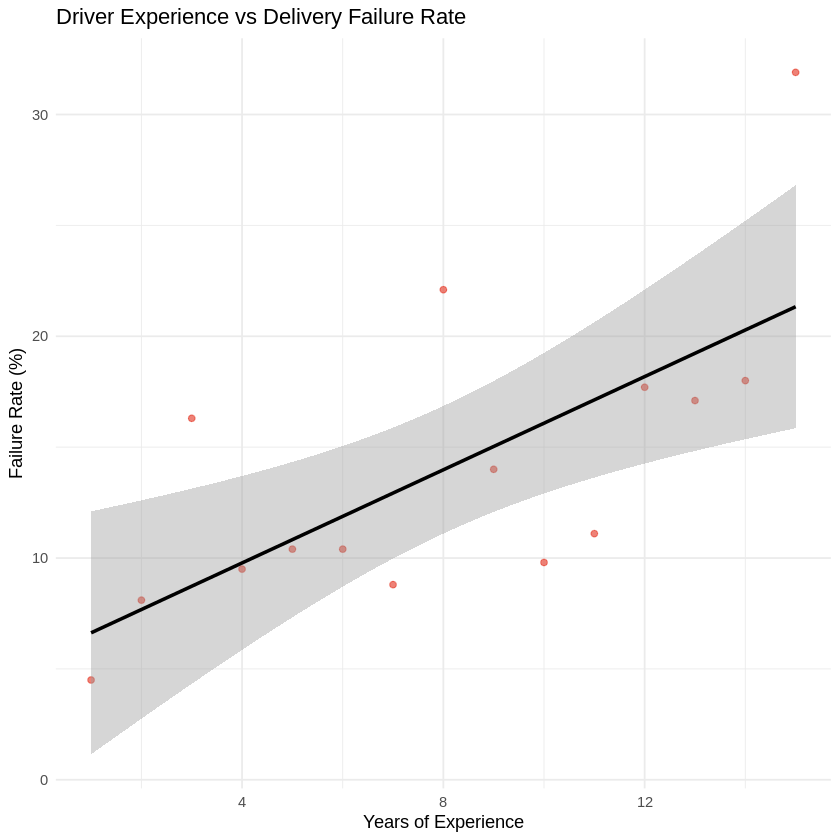

In [23]:
#1 Scatter plot version
ggplot(driver_performance, aes(x = years_experience, y = fail_rate)) +
  geom_point(color = "#e74c3c", alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE, color = "black") +
  labs(
    title = "Driver Experience vs Delivery Failure Rate",
    x = "Years of Experience",
    y = "Failure Rate (%)"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


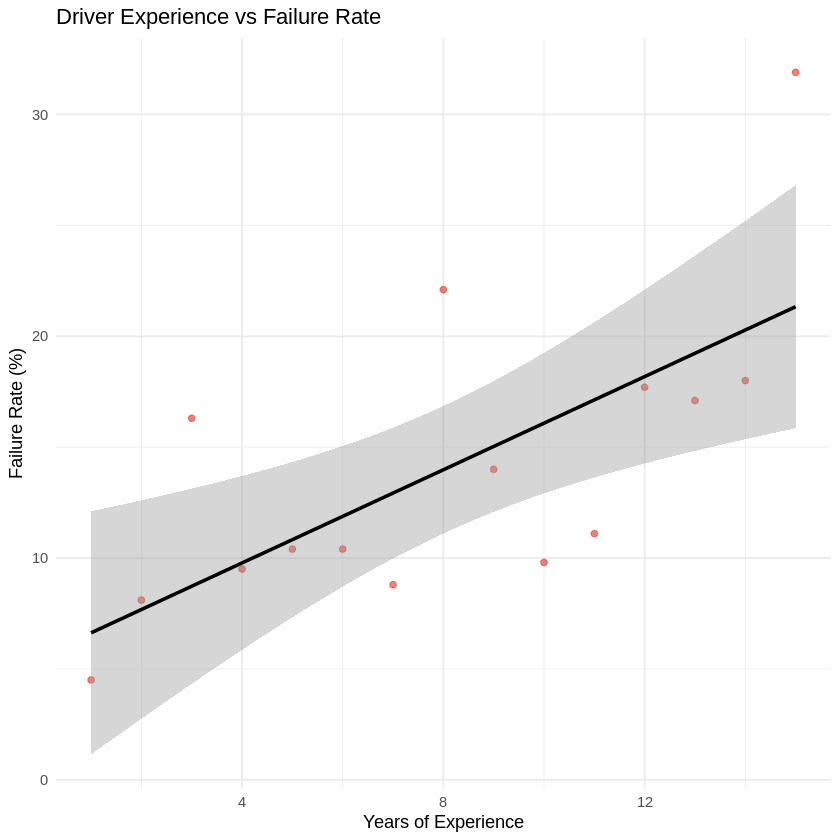

In [24]:
# SS14: Scatter plot with trend line
driver_performance <- deliveries %>%
  left_join(drivers, by = "driver_id") %>%
  filter(!is.na(years_experience)) %>%
  mutate(is_failed = ifelse(delivery_status == "Failed", 1, 0)) %>%
  group_by(years_experience) %>%
  summarise(
    total = n(),
    failures = sum(is_failed),
    fail_rate = round(100 * failures / total, 1)
  )

ggplot(driver_performance, aes(x = years_experience, y = fail_rate)) +
  geom_point(color = "#e74c3c", alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE, color = "black") +
  labs(
    title = "Driver Experience vs Failure Rate",
    x = "Years of Experience",
    y = "Failure Rate (%)"
  ) +
  theme_minimal()